In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd
df_train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df_train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df_train.drop(['Cabin'], axis=1, inplace=True)

In [6]:
df_train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [7]:
df_train['Embarked'].fillna('S', inplace=True)

/tmp/ipykernel_16/3339411154.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Embarked'].fillna('S', inplace=True)


In [8]:
embarked = {"Embarked": {"S": 0, "C": 1, "Q": 2}}
df_train.replace(embarked, inplace=True)
sex = {"Sex": {"male": 0, "female": 1 }}
df_train.replace(sex, inplace=True)
df_train.head()

/tmp/ipykernel_16/2552612888.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train.replace(embarked, inplace=True)
/tmp/ipykernel_16/2552612888.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train.replace(sex, inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


In [9]:
male = df_train['Age'].loc[df_train['Sex'] == 0].mean()
female = df_train['Age'].loc[df_train['Sex'] == 1].mean()
print('male=', male, 'female=', female)

male= 30.72664459161148 female= 27.915708812260537


In [10]:
df_train.loc[(df_train['Sex'] == 0) & (df_train['Age'].isnull()), 'Age'] = 30.7266445916114

In [11]:
df_train.loc[(df_train['Sex'] == 1) & (df_train['Age'].isnull()), 'Age'] = 27.9157081226057

<Axes: >

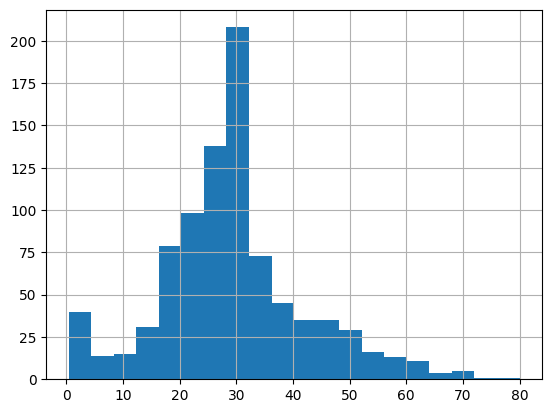

In [12]:
df_train['Age'].hist(bins=20)

In [13]:
age = [0,5,15,25,30,35,45,50,200]
age_label = ['0-5','5-15','15-25','25-30','30-35','35-40','45-50','>50']
age_group = pd.cut(df_train['Age'], age, labels=age_label)
df_train['age_group'] = age_group
df_train['age_group_code'] = df_train['age_group'].cat.codes
df_train['age_group'].value_counts()

age_group
15-25    218
30-35    212
25-30    161
35-40    114
>50       64
0-5       44
5-15      39
45-50     39
Name: count, dtype: int64

<Axes: >

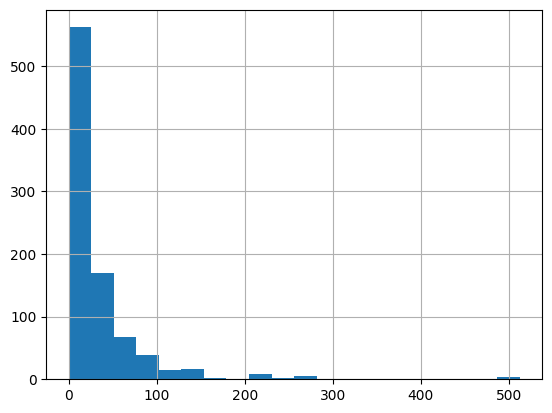

In [14]:
df_train['Fare'].hist(bins=20)

In [15]:
price = [0, 10, 30, 35, 80, 1000]
price_label = ['0-10', '10-30', '30-35', '35-80','>80']
price_group = pd.cut(df_train['Fare'], price,  labels= price_label)
df_train['price_group'] = price_group
df_train['price_group_code'] = df_train['price_group'].cat.codes

In [16]:
df_train['price_group'].value_counts()

price_group
0-10     321
10-30    321
35-80    124
>80       74
30-35     36
Name: count, dtype: int64

In [17]:
SumPeople = df_train['SibSp'].astype(int) + df_train['Parch'].astype(int) + 1
df_train['SumPeople'] = SumPeople.astype(int)

In [18]:
df_train['SumPeople'].value_counts()

SumPeople
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [19]:
import sklearn.model_selection as ms
features = df_train[['Pclass', 'Embarked','Sex','age_group_code','price_group_code','SumPeople']]
labels = df_train['Survived']
X_train, X_test, y_train, y_test =  ms.train_test_split(features, labels, test_size=0.25, random_state=0)

In [20]:
import sklearn.naive_bayes as nb
import sklearn.metrics as met
gnb = nb.GaussianNB()
gnb.fit(X_train, y_train)
y_prediction = gnb.predict(X_test)
accuracy = met.accuracy_score(y_test, y_prediction)
precision = met.precision_score(y_test, y_prediction)
print('Accuracy=', accuracy, 'Precision=', precision)

Accuracy= 0.8161434977578476 Precision= 0.7311827956989247


In [21]:
df_test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [22]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [23]:
embarked = {"Embarked": {"S": 0, "C": 1, "Q": 2}}
df_test.replace(embarked, inplace=True)
sex = {"Sex": {"male": 0, "female": 1 }}
df_test.replace(sex, inplace=True)
df_test.head()

/tmp/ipykernel_16/3993633414.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test.replace(embarked, inplace=True)
/tmp/ipykernel_16/3993633414.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test.replace(sex, inplace=True)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,2
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,0
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NaN,2
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NaN,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,0


In [24]:
df_test.loc[(df_test['Sex'] == 0) & (df_test['Age'].isnull()), 'Age'] = 30.7266445916114
df_test.loc[(df_test['Sex'] == 1) & (df_test['Age'].isnull()), 'Age'] = 27.9157081226057

In [25]:
df_test.drop(['Cabin'], axis=1, inplace=True)

In [26]:
fare_median = df_train['Fare'].median()
df_test['Fare'] = df_test['Fare'].fillna(fare_median)

In [27]:
age = [0,5,15,25,30,35,45,50,200]
age_label = ['0-5','5-15','15-25','25-30','30-35','35-40','45-50','>50']
age_group = pd.cut(df_test['Age'], age, labels=age_label)
df_test['age_group'] = age_group
df_test['age_group_code'] = df_test['age_group'].cat.codes
df_test['age_group'].value_counts()

age_group
15-25    110
30-35     88
25-30     83
35-40     53
>50       31
45-50     21
5-15      20
0-5       12
Name: count, dtype: int64

In [28]:
price = [0, 10, 30, 35, 80, 1000]
price_label = ['0-10', '10-30', '30-35', '35-80','>80']
price_group = pd.cut(df_test['Fare'], price,  labels= price_label)
df_test['price_group'] = price_group
df_test['price_group_code'] = df_test['price_group'].cat.codes

In [29]:
SumPeople = df_test['SibSp'].astype(int) + df_test['Parch'].astype(int) + 1
df_test['SumPeople'] = SumPeople.astype(int)

In [30]:
gnb_final = nb.GaussianNB()
gnb_final.fit(features, labels)  # full features & labels, not X_train


features_test = df_test[['Pclass', 'Embarked', 'Sex', 'age_group_code', 'price_group_code', 'SumPeople']]


test_predictions = gnb_final.predict(features_test)


submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': test_predictions
})
submission.to_csv('submission.csv', index=False)